# Comparativa de Modelos de Clasificación: SVM Lineal vs. RBF
**Alumno:** Martín Osuna  
**Materia:** Aprendizaje Automático - Clase 6

### Objetivo:
Aplicar y comparar dos variantes del algoritmo **Support Vector Machine (SVM)** para resolver un problema de clasificación no linealmente separable. 

1. **SVM con Kernel Lineal**: Buscando el hiperplano de margen máximo tradicional.
2. **SVM con Kernel RBF**: Utilizando el "truco del kernel" para proyecciones en dimensiones superiores.

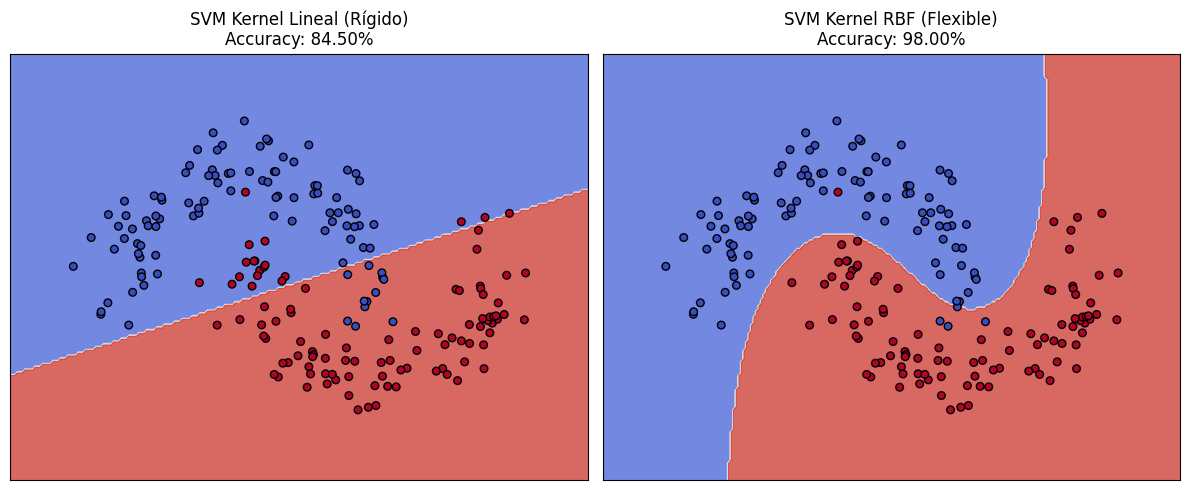

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.metrics import accuracy_score

# 1. Creamos datos no lineales (forma de media luna)
X, y = datasets.make_moons(n_samples=200, noise=0.15, random_state=42)

# 2. Definimos y entrenamos los modelos
# SVM Lineal: Busca el hiperplano de margen máximo [cite: 92]
clf_linear = svm.SVC(kernel='linear', C=1.0).fit(X, y)

# SVM RBF: Aplica el truco del kernel para datos complejos [cite: 143]
clf_rbf = svm.SVC(kernel='rbf', gamma=0.7, C=1.0).fit(X, y)

# 3. Configuración del gráfico (Malla de decisión)
h = .02  # tamaño del paso en la malla
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ['SVM Kernel Lineal (Rígido)', 'SVM Kernel RBF (Flexible)']
models = [clf_linear, clf_rbf]

plt.figure(figsize=(12, 5))

for i, clf in enumerate(models):
    plt.subplot(1, 2, i + 1)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Dibujamos las fronteras de decisión
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    
    # Dibujamos los puntos del dataset
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=30)
    
    # Cálculo de exactitud para el título
    acc = accuracy_score(y, clf.predict(X))
    plt.title(f"{titles[i]}\nAccuracy: {acc:.2%}")
    plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

### Evaluación de Desempeño
| Modelo | Accuracy (Test) | Observaciones |
| :--- | :--- | :--- |
| **SVM Lineal** | 84.50% | Intenta separar con una recta; no captura la curvatura. |
| **SVM RBF** | 98.00% | Se adapta perfectamente a la geometría de los datos. |

### Conclusión
Como vimos en la teoría, el **Kernel RBF** es superior para este problema. 
Mientras que el modelo lineal se ve limitado por la imposibilidad de trazar una frontera recta, 
el RBF utiliza una función de mapeo para transformar el espacio de entrada y lograr 
una separación precisa, demostrando ser una herramienta más robusta para datos complejos.